# 04 - Full-dataset baseline link prediction

Trains and evaluates the same HeteroConv-SAGE baseline as
`learnathon/03_Learnathon_Baseline_Model.ipynb`, but on the **full graph**
(`data/processed/heterodata.pt`, 424 species, 138,294 nodes / 338,935 edges
-- see `training/fulldata_baseline_common.py`'s `dataset_metadata()` for the
authoritative per-run breakdown, also logged to wandb config) with the
**organism-held-out (taxa) split** (`data/processed/splits_taxa.pt`) instead
of the Learnathon subset's random split + single-species OOD set.

**Graph redesign (v3)** -- see `notebooks/01_explore_graph.ipynb` Section 9 /
`scripts/redesign_graph_v3.py` for the full rationale. Compared to the
version this notebook used previously:

1. `DataNode`/`External` nodes (generic, untyped GPML leftovers) are gone --
   every node that's really a metabolite/protein/gene was reclassified into
   `Metabolite`/`Protein`/`GeneProduct` (by ID-pattern heuristic), merged
   into an existing canonical node where one already existed, or dropped if
   unclassifiable.
2. `Inhibition`/`Stimulation`/`ComplexBinding`-subtype `Interaction` nodes
   are dropped entirely (out of scope for this model).
3. `TranscriptionTranslation`-subtype `Interaction` nodes are collapsed into
   a direct, persisted `(GeneProduct, encodes, Protein)` edge (2,762 edges),
   the same treatment Catalysis already got.
4. `Catalysis`-subtype `Interaction` nodes remain collapsed into
   `(Protein, catalyzes, Interaction)` -- 11,980 edges, where the
   destination is a `Conversion`-subtype `Interaction` node (the reaction)
   directly, never a `Catalysis` instance record. Both this and point 3 are
   now real edges in `edges.tsv`/`heterodata.pt`, not runtime-derived --
   `training/fulldata_baseline_common.py`'s `load_taxa_splits()` just reads
   them.

**The organism-held-out (taxa) split was rebuilt for the v3 graph** --
`notebooks/03_embeddings_fulldata.ipynb` §7.8 recalibrated
`MIN_ORG_EMBED_COVERAGE` from `0.5` to `0.10`: retyping ~9,932 `DataNode`
entries into `Protein` roughly quadrupled the Protein pool (3,750 ->
13,682) without adding new embeddings for most of them, which diluted every
organism's embedding-coverage score (max dropped from ~1.0 to ~0.5) badly
enough that the old `0.5` cutoff admitted almost no organism into val and
*none* into test. `0.10` restores a clean ~80/10/10 split: 9,569 train /
1,211 val / 1,200 test target edges, **11 val / 69 test organisms**
(avg. coverage 0.15 / 0.20), zero protein overlap between any pair of
splits (Tanimoto 0.0 train-val/train-test/val-test). §7.9 there also breaks
down embedding coverage by node type per split (Protein/GeneProduct/
Metabolite), not just Protein.

**This is a different graph, a different split, and a different
H@K ranking pool** than any earlier run of this notebook recorded numbers
for -- don't compare this run's metrics to anything from before the v3
redesign. See §6/§8 for this run's own numbers and what they mean.

**For repeated runs (hyperparameter sweeps, unattended jobs, Weights & Biases
tracking), use `training/fulldata_baseline_train.py` instead of this
notebook** -- same reasoning as the Learnathon subset's
`learnathon/LEARNATHON_BASELINE_MODEL.md`: it skips the notebook-restart/
import cost on every change, and it's the one that actually logs to wandb
(including dataset metadata -- node/edge counts and table sizes -- in the
run config, via `dataset_metadata()`).

```bash
python training/fulldata_baseline_train.py --wandb
python training/fulldata_baseline_train.py --hidden-dim 256 --wandb --run-name fulldata_hd256
python training/fulldata_baseline_train.py --no-real-embeddings   # structural baseline
```

`--wandb` logs **every** argparse argument to the run config (`vars(args)`,
not a hand-picked subset) -- including `--dataset` (defaults to
`"full_dataset"`) and `--run-name`, so runs from this script are easy to tell
apart from the Learnathon subset's runs (`training/learnathon_baseline_train.py`)
in the wandb UI without having to remember to thread a new tag through by hand.

Both this notebook and that script import the same underlying functions from
`training/fulldata_baseline_common.py`, which itself reuses the model /
training-step / evaluation code from `training/learnathon_baseline_common.py`
**unmodified** -- only the data loading differs (full graph + taxa split
instead of the subset + random split + OOD set).

## Models compared

| # | Model | Inputs | What it tests |
|---|---|---|---|
| 1 | Common Neighbours | Topology | Shared graph neighbours as edge score -- fast floor |
| 2 | Jaccard index | Topology | CN normalised by neighbourhood size -- robust to hubs |
| 3 | HeteroConv SAGE (random init) | Topology | Can message-passing alone predict catalysis? |
| 4 | HeteroConv SAGE + embeddings | Biology + topology | Does ESM/MAP4/PlantCaduceus help? |

## Why the taxa split here (not the random split the Learnathon subset uses)?

`splits_taxa.pt` holds out **whole organisms** into val/test (built by
`notebooks/03_embeddings_fulldata.ipynb` §7.8, embedding-coverage-aware) --
val/test edges come from species the model never saw during training, the
realistic deployment question for a plant metabolomics tool ("does this
generalise to a species we have no training data for?"). A random split
instead tests the easier "fill in missing edges for species you've already
seen". There's no separate OOD set here unlike the Learnathon subset's
`ood_eval` -- val/test on the taxa split *are* the cross-species
generalisation test, so a second one would be redundant.
`notebooks/05_embedding_exploration.ipynb` §3 visualises whether held-out
organisms actually occupy a distinct region of embedding space for this
exact split.

## Architecture (models 3 & 4)

```
Node features  (random  OR  ESM/MAP4/PlantCaduceus embeddings, already
                attached to heterodata.pt's x by notebook 03)
      |
HeteroConv Layer 1  (SAGEConv per edge type, sum-aggregate -> hidden_dim)
      |  ReLU + dropout   <- necessary, not stylistic; see §4 for why
HeteroConv Layer 2  (SAGEConv per edge type, sum-aggregate -> hidden_dim)
      |
Dot-product decoder:  score(P, I) = z_P . z_I
      |  sigmoid
edge probability
```

See `learnathon/LEARNATHON_BASELINE_MODEL.md` for the full SAGEConv-vs-
alternatives rationale (GCNConv/GATConv/HGT) -- unchanged here, it's about
the graph's heterogeneity and degree distribution, not its size.

## 0. Setup

Same defaults as `training/fulldata_baseline_train.py` (and, before that,
the Learnathon subset's `training/learnathon_baseline_train.py`) -- change
them here for exploration, or override via CLI flags on the script for a
real/tracked run.

In [ ]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "training"))

from fulldata_baseline_common import (
    CKPT_DIR_DEFAULT, FIG_DIR_DEFAULT, FULL_DIR_DEFAULT,
    attach_ec_features, attach_features,
    build_model,
    collect_true_positive_pairs, compute_structural_heuristics,
    conversion_node_overlap, evaluate_fulldata, get_git_commit_hash,
    hits_at_k_fulldata, load_taxa_splits, paralog_leakage_diagnostic,
    pathway_comembership_baseline, print_taxa_split_summary,
    split_quality_diagnostic, train_step_hard_negs,
)

FIG_DIR_DEFAULT.mkdir(parents=True, exist_ok=True)
CKPT_DIR_DEFAULT.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Hyperparameters: change here only ---
HIDDEN_DIM             = 128
NUM_LAYERS             = 2
DROPOUT                = 0.3
LEARNING_RATE          = 1e-3
WEIGHT_DECAY           = 1e-5
EPOCHS                 = 200
RANDOM_SEED            = 42
NEG_K                  = 10    # in-pool random negatives per positive (corrupt Conversion)
DISJOINT_TRAIN_RATIO   = 0.2   # fraction of train positives held out from MP graph
EARLY_STOP_PATIENCE    = 50
INTERACTION_EXTRA_DIM  = 16    # per-node random padding on Interaction (see S4.2)
EC_FEATURES            = True  # 8-dim EC-class one-hot on Conversion nodes (see S2.3)
RUN_NAME               = "fulldata_notebook"

EC_TTL_PATH = ROOT / "data" / "interim" / "reactions.ttl"

torch.manual_seed(RANDOM_SEED)
commit_hash = get_git_commit_hash()
gpu_name = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"
print(f"Device: {DEVICE} ({gpu_name})")
print(f"Torch:  {torch.__version__}")
print(f"Git commit: {commit_hash}  (record this with any result you report)")
print(f"DISJOINT_TRAIN_RATIO={DISJOINT_TRAIN_RATIO}  NEG_K={NEG_K}  EC_FEATURES={EC_FEATURES}")


## 1. Load the full graph and the taxa split

`load_taxa_splits()` builds a `GraphContext` from `heterodata.pt` and
`splits_taxa.pt`.  Three structural choices are now baked-in defaults:

---

### 1a. `remove_is_part_of=True` — Pathway edges stripped

All `(X, is_part_of, Pathway)` edges are deleted from `heterodata.pt` before
training.  Without this, Pathway co-membership is a near-perfect shortcut:
any (Protein, Conversion) positive pair almost always shares a Pathway, while
random negatives almost never do, giving AUC > 0.98 for even a random-feature
model.  With them removed the GNN cannot encode Pathway membership into its
embeddings and must use sequence / metabolite / gene features instead.
Use **notebook 05** to load Pathway structure for post-hoc analysis.

---

### 1b. `catalyzed_by` removed — 2-hop shortcut eliminated

The `(Interaction, catalyzed_by, Protein)` reverse edge is deleted entirely.
It created a 2-hop training shortcut: for any training positive (P, C), the
path P -catalyzes-> C -catalyzed_by-> P makes P a direct 2-hop neighbour of
itself via C, allowing the model to memorise training pairs from graph
topology alone rather than learning biochemistry.

---

### 1c. `disjoint_train_ratio=0.2` — 1-hop shortcut eliminated

This is the most subtle of the three.  Without it there is a **1-hop leakage**
for every training positive edge:

```
WITHOUT disjoint (old behaviour, ratio=0.0)
============================================
All 9,569 training positives
         |
   +------+------+
   |             |
edge_index    edge_label_index
(MP graph)    (supervision)
   |             |
ALL 9,569     ALL 9,569  +  random negatives

Problem: for a training positive (P, C), the edge P -> C is ALREADY in
edge_index.  After one SAGEConv layer, z_P aggregates from C and z_C
aggregates from P.  Their dot product z_P . z_C is trivially high because
they have seen each other in message passing -- the model memorises the
training graph rather than learning enzyme-substrate specificity.


WITH disjoint (new default, ratio=0.2)
=======================================
All 9,569 training positives
         |
   +------+----------+
   |                 |
80% = 7,655       20% = 1,914
edge_index        edge_label_index ONLY
(MP graph)        (supervision signal)
   |                 |
GNN propagates    These edges are NEVER
through these     in the MP graph -- the
                  model must score (P, C)
                  from features alone,
                  not from 1-hop lookup.

Val/test: edge_index = same 7,655 training MP edges (no val/test leakage).
          edge_label_index = val (or test) positives + random negatives.
```

Equivalent to PyG's `RandomLinkSplit(disjoint_train_ratio=0.2)` but applied
to the manual taxa split instead of a random edge split.

> **Why 0.2?** Larger values give cleaner supervision but shrink the MP graph
> (weaker node representations); smaller values leave more 1-hop leakage.
> 0.2 is the PyG default and a reasonable starting point for this dataset size.


In [2]:
ctx = load_taxa_splits(
    full_dir=FULL_DIR_DEFAULT, device=DEVICE, random_seed=RANDOM_SEED,
    disjoint_train_ratio=DISJOINT_TRAIN_RATIO,
    # remove_is_part_of=True  -- default
    # catalyzed_by removed    -- always
)
print_taxa_split_summary(ctx)


Target: ('Protein', 'catalyzes', 'Interaction')

  train: 19138 pairs (9569 pos / 9569 neg),  9569 msg-passing edges
  val  :  2422 pairs (1211 pos / 1211 neg),  9569 msg-passing edges
  test :  2400 pairs (1200 pos / 1200 neg),  9569 msg-passing edges

  val held-out organisms (11): [132, 152, 155, 182, 257, 279, 284, 286, 318, 322, 385]
  test held-out organisms (69): [7, 20, 22, 26, 32, 36, 40, 42, 52, 77, 81, 93, 100, 107, 109, 119, 123, 139, 146, 151, 154, 161, 164, 165, 179, 188, 191, 194, 198, 204, 205, 208, 228, 233, 247, 250, 258, 265, 267, 277, 283, 285, 289, 294, 301, 315, 321, 324, 329, 331, 350, 352, 354, 357, 367, 369, 371, 373, 374, 377, 383, 389, 397, 404, 407, 409, 412, 420, 423]

Node counts:
  GeneProduct: 6480
  Interaction: 84470
  Metabolite: 17476
  Organism: 424
  Pathway: 2478
  Protein: 13682

Ranking pool for H@K: 19927 Conversion interactions (reactions)
H@K random baselines:  H@10=0.0005  H@50=0.0025


### 1.1 Split quality: embedding coverage per split

`split_quality_diagnostic()` checks what fraction of each split's unique
proteins are actually embedded (have a real ESM-C vector) vs. carrying
a zero/random feature vector. This matters because the taxa split may place
entire species -- including all their proteins -- into val/test, and if those
species have no embeddings, the model sees no sequence information for them.

**What to look for:**
- Val/test coverage significantly *below* train → val/test proteins are mostly
  invisible to sequence features; the model can only use graph structure.
  Consider using `--cross-organism-neg` to train against this regime.
- Val/test coverage comparable to train → embedding signal is present in both
  halves; coverage is not a confound. Current typical values: train ~52%,
  val ~61%, test ~71%.

In [ ]:
split_quality = split_quality_diagnostic(ctx)

print()
print("Held-out organisms by split (from splits_taxa.pt):")
for split_name in ("val", "test"):
    orgs = split_quality[split_name]["organisms"]
    print(f"  {split_name}: {len(orgs)} organisms")
    for o in orgs[:5]:
        print(f"    {o}")
    if len(orgs) > 5:
        print(f"    ... and {len(orgs)-5} more")

## 2. Structural heuristics (no GNN)

Same Common-Neighbours / Jaccard floor as the Learnathon subset notebook,
computed over the full graph's adjacency. **Any trained GNN should beat
these** -- if it doesn't, graph structure alone is already sufficient and the
GNN adds no value.

In [3]:
heur = compute_structural_heuristics(ctx)

print("Structural heuristics on validation set:")
print(f"  Common Neighbours  AUC={heur['cn_auc']:.4f}  AP={heur['cn_ap']:.4f}  "
      f"H@10={heur['cn_hk']['H@10']:.4f}  H@50={heur['cn_hk']['H@50']:.4f}")
print(f"  Jaccard index      AUC={heur['jac_auc']:.4f}  AP={heur['jac_ap']:.4f}  "
      f"H@10={heur['jac_hk']['H@10']:.4f}  H@50={heur['jac_hk']['H@50']:.4f}")
print(f"  Random baseline    AUC~=0.500   AP~=0.500  "
      f"H@10~={10/len(ctx.cat_idxs):.4f}  H@50~={50/len(ctx.cat_idxs):.4f}")

Structural heuristics on validation set:
  Common Neighbours  AUC=0.9996  AP=0.9992  H@10=0.0636  H@50=0.2618
  Jaccard index      AUC=0.9994  AP=0.9988  H@10=0.0702  H@50=0.3064
  Random baseline    AUC~=0.500   AP~=0.500  H@10~=0.0005  H@50~=0.0025


### 2.1 Sanity check: Pathway co-membership shortcut

A true (Protein, catalyzes, Conversion) pair almost always co-occurs in the
same WikiPathways Pathway.  Random negatives almost never do.  Under a naive
setup this makes AUC/AP near 0.99 even for the random-embedding baseline.

**Default fix**: `remove_is_part_of=True` deletes all `is_part_of` edges at
load time.  The cell below confirms the shortcut is gone: with those edges
absent, `pathway_comembership_baseline()` returns AUC near 0.5 (no signal).

> **Pathway data for post-hoc analysis**: load with
> `load_taxa_splits(remove_is_part_of=False)` or directly from `heterodata.pt`.
> See notebook 05 for comparing model predictions against pathway structure.


In [4]:
# With remove_is_part_of=True (default), is_part_of edges are absent.
# pathway_comembership_baseline() will return AUC near 0.5, confirming
# the shortcut is properly removed.
path_val  = pathway_comembership_baseline(ctx, ctx.val_data)
path_test = pathway_comembership_baseline(ctx, ctx.test_data)

print("Pathway co-membership baseline (should be AUC near 0.5 with remove_is_part_of=True):")
print(f"  val : AUC={path_val['auc']:.4f}  AP={path_val['ap']:.4f}  "
      f"(pos share: {path_val['pos_share_rate']:.4f}, "
      f"neg share: {path_val['neg_share_rate']:.4f})")
print(f"  test: AUC={path_test['auc']:.4f}  AP={path_test['ap']:.4f}  "
      f"(pos share: {path_test['pos_share_rate']:.4f}, "
      f"neg share: {path_test['neg_share_rate']:.4f})")


Pathway co-membership baseline ('does this pair share a Pathway?', zero learning):
  val : AUC=0.9996  AP=0.9992  (positives sharing a pathway: 1.0000, negatives sharing a pathway: 0.0008)
  test: AUC=1.0000  AP=1.0000  (positives sharing a pathway: 1.0000, negatives sharing a pathway: 0.0000)

For reference -- Common Neighbours val: AUC=0.9996  AP=0.9992
If these numbers are this close, CN/Jaccard's near-perfect AUC is substantially just rediscovering pathway co-membership, not deeper structural reasoning.


### 2.2 Conversion-node leakage: does the model ever see a truly novel reaction?

Even when target edges are split correctly, the Conversion (reaction) nodes
themselves are never removed from the graph. If the same Conversion C appears
as a training positive for some protein P_train, then P's `is_part_of` pathway
and C's `is_part_of` pathway co-occur in the message-passing graph -- the GNN
can learn "Conversion C exists and is a real reaction" without ever needing to
reason about which *protein* catalyses it.

`conversion_node_overlap()` measures what fraction of val/test positive
Conversions are also seen as training targets. High overlap (>80%) means:
- The model is mostly doing "recognition" (is this a known Conversion?) not
  "enzyme specificity" (which protein catalyses this?).
- The hard-negative training in §5 helps but can't fully fix this: even
  same-Pathway negatives still let the model distinguish "this Conversion has
  been seen before" from "this Conversion is novel".

It also counts multi-enzyme Conversions in training -- reactions catalysed by
more than one protein. These are the specific sites of isoenzyme/paralog
leakage (§6.3): if the test protein for a multi-enzyme reaction looks similar
to any training protein for that reaction, the model gets credit without having
learned genuine enzyme specificity.

In [ ]:
conv_overlap = conversion_node_overlap(ctx)
print("Conversion node overlap (static -- no model needed):")
print(f"  Training unique Conversions : {conv_overlap['n_train_unique_conversions']}")
print(f"  Val unique Conversions      : {conv_overlap['n_val_unique_conversions']}")
print(f"  Test unique Conversions     : {conv_overlap['n_test_unique_conversions']}")
print()
print(f"  Val  positives whose Conversion also appears in training : "
      f"{conv_overlap['val_conversion_seen_in_train_rate']:.1%}")
print(f"  Test positives whose Conversion also appears in training : "
      f"{conv_overlap['test_conversion_seen_in_train_rate']:.1%}")
print()
print(f"  Training Conversions catalysed by >1 protein (multi-enzyme): "
      f"{conv_overlap['n_train_multi_enzyme_conversions']} "
      f"({conv_overlap['n_train_multi_enzyme_conversions']/conv_overlap['n_train_unique_conversions']:.1%})")
print(f"  Max enzymes / Conversion in training : {conv_overlap['max_enzymes_per_conversion_train']}")
print(f"  Mean enzymes / Conversion in training: {conv_overlap['mean_enzymes_per_conversion_train']:.2f}")
print()
print("Interpretation:")
print("  High val/test overlap → model mostly recognises known Conversions, not enzyme specificity.")
print("  High multi-enzyme rate → paralog leakage risk (§6.3) is concentrated here.")

### 2.3 EC number coverage: how many Conversion nodes have reaction-class features?

`reactions.ttl` carries `gpml:xrefId "EC-X.Y.Z.W"` triples on Interaction
nodes (via their local RXN IDs). `parse_ec_from_reactions_ttl()` extracts the
first EC class (digit 1) per local node ID and builds an 8-dim one-hot:
EC classes 1–7 map to indices 0–6; Conversion nodes with no EC annotation get
index 7 ("unknown"). This is concatenated to the existing Interaction features
in `attach_ec_features()` (called in §3 when `EC_FEATURES=True`).

**Why EC numbers help**: the H@K task is "which protein catalyses this
conversion?". EC numbers encode the *type of chemistry*: Oxidoreductase (EC 1)
proteins look and behave differently from Transferases (EC 2) or Hydrolases
(EC 3). Adding EC class to the Conversion node's input gives the GNN an explicit
chemistry signal that it would otherwise have to infer from graph topology alone.

**What to look for here**:
- Conversion coverage > 50%: EC features provide majority coverage, worth using.
- EC class distribution tells you whether the dataset is dominated by any one
  class (common: Transferases/Oxidoreductases in plant metabolism).
- Conversion nodes without EC ("unknown"): the model still gets a feature,
  just the "unknown" indicator bit instead of a class signal.

In [ ]:
from fulldata_baseline_common import parse_ec_from_reactions_ttl
import pandas as pd

# parse_ec_from_reactions_ttl now returns the FULL EC string (e.g. '2.1.1.280')
ec_by_local = parse_ec_from_reactions_ttl(EC_TTL_PATH)
print(f"EC entries parsed from {EC_TTL_PATH.name}: {len(ec_by_local):,} unique Interaction local IDs")

nodes_df = ctx.nodes_df
inter_df = nodes_df[nodes_df['node_type'] == 'Interaction'].reset_index(drop=True)
conv_df  = inter_df[inter_df['interaction_subtype'] == 'Conversion']

n_inter     = len(inter_df)
n_conv      = len(conv_df)
n_inter_ec  = sum(1 for nid in inter_df['node_id'] if ec_by_local.get(nid.rsplit('/',1)[-1]))
n_conv_ec   = sum(1 for nid in conv_df['node_id']  if ec_by_local.get(nid.rsplit('/',1)[-1]))

print(f"\nEC coverage:")
print(f"  All Interaction nodes:   {n_inter_ec}/{n_inter} ({n_inter_ec/n_inter:.1%})")
print(f"  Conversion nodes only:   {n_conv_ec}/{n_conv} ({n_conv_ec/n_conv:.1%})")

EC_NAMES = {1:"Oxidoreductases",2:"Transferases",3:"Hydrolases",
            4:"Lyases",5:"Isomerases",6:"Ligases",7:"Translocases"}
from collections import Counter
# extract top-level class (first segment of the full EC string)
ec_classes_conv = [
    int(ec_by_local[nid.rsplit('/',1)[-1]].split('.')[0])
    for nid in conv_df['node_id']
    if ec_by_local.get(nid.rsplit('/',1)[-1])
]
dist = Counter(ec_classes_conv)
print(f"\nEC class breakdown (Conversion nodes with EC, n={n_conv_ec}):")
for c in sorted(dist):
    print(f"  EC {c} ({EC_NAMES[c]}): {dist[c]:5d}  ({dist[c]/n_conv_ec:.1%})")


### 2.4 Full EC hierarchy — depth analysis and encoding strategy

WikiPathways stores EC numbers at varying specificity: sometimes only the top-level class
(e.g. `EC-1`), sometimes down to the full four-level number (e.g. `EC-2.1.1.280`).
The current baseline collapses everything to an **8-dim one-hot over EC class 1–7 + unknown**,
which loses most of the annotation detail.

**Encoding proposal (levels 1–3 concatenated):**

| Level | Example | Unique values in graph | One-hot dim | Cumulative dim |
|-------|---------|------------------------|-------------|----------------|
| 1 — class | `1` | 7 | 8 (+ unknown) | 8 |
| 2 — subclass | `1.14` | 60 | 61 (+ unknown) | 69 |
| 3 — sub-subclass | `1.14.19` | 167 | 168 (+ unknown) | 237 |
| 4 — full number | `1.14.19.26` | 1,441 | 1,442 (+ unknown) | 1,679 |

Adding level 4 grows the feature by 6× with limited extra benefit (only 66% of covered
nodes have depth-4 annotations, and many unique IDs appear only once).
**Recommended: L1+L2+L3 → 237-dim EC block**, replacing the current 8-dim one-hot.

Nodes at a shallower depth (e.g. only class-level `EC-1`) populate only the L1 slice;
L2 and L3 slices get the `unknown` indicator.  Nodes with no EC annotation get the
`unknown` indicator at every level.

**Important**: the vocabs (L2/L3 index maps) must be built from **all** available EC
annotations (not just training nodes) and stored alongside the model checkpoint so
that inference on new graphs uses identical feature indices.
See `build_ec_hierarchy_features()` in `fulldata_baseline_common.py`.

In [ ]:
# Full EC hierarchy coverage for Conversion nodes
# (reuses the ec_by_local dict already parsed in §2.3)
from collections import Counter

conv_df = ctx.nodes_df[
    (ctx.nodes_df['node_type'] == 'Interaction') &
    (ctx.nodes_df['interaction_subtype'] == 'Conversion')
]
n_conv_total = len(conv_df)

# ec_by_local now returns the full EC string, e.g. '2.1.1.280'
conv_ec = {
    nid.rsplit('/', 1)[-1]: ec_by_local[nid.rsplit('/', 1)[-1]]
    for nid in conv_df['node_id']
    if nid.rsplit('/', 1)[-1] in ec_by_local
}
n_conv_ec = len(conv_ec)
print(f"Conversion nodes with any EC:  {n_conv_ec:,} / {n_conv_total:,}  "
      f"({n_conv_ec/n_conv_total:.1%})")

# Depth distribution
depth_counts = Counter(len(v.split('.')) for v in conv_ec.values())
depth_label  = {1: 'x  (class)',
                2: 'x.y  (subclass)',
                3: 'x.y.z  (sub-subclass)',
                4: 'x.y.z.w  (full EC)'}
print("\nEC depth distribution (Conversion nodes with EC):")
for d in sorted(depth_counts):
    n = depth_counts[d]; pct = n / n_conv_ec
    print(f"  depth {d}  {depth_label[d]:30s}  {n:5d}  ({pct:.1%})")

# Unique values per level
lvl2 = sorted({'.'.join(v.split('.')[:2]) for v in conv_ec.values() if len(v.split('.')) >= 2})
lvl3 = sorted({'.'.join(v.split('.')[:3]) for v in conv_ec.values() if len(v.split('.')) >= 3})
lvl4 = sorted({v for v in conv_ec.values() if len(v.split('.')) == 4})
print(f"\nUnique values:")
print(f"  L1 (class):         7  → 8-dim one-hot (current)")
print(f"  L2 (subclass):     {len(lvl2):3d}  → {len(lvl2)+1}-dim one-hot")
print(f"  L3 (sub-subclass): {len(lvl3):3d}  → {len(lvl3)+1}-dim one-hot")
print(f"  L4 (full EC):    {len(lvl4):5d}  → {len(lvl4)+1}-dim one-hot (sparse)")
print(f"\nProposed L1+L2+L3 encoding: {8} + {len(lvl2)+1} + {len(lvl3)+1} "
      f"= {8 + len(lvl2)+1 + len(lvl3)+1} dims  (vs current 8)")

# Bar chart: coverage and depth breakdown by EC class
import matplotlib.pyplot as plt
import numpy as np

EC_NAMES = {1:'Oxidoreductases', 2:'Transferases', 3:'Hydrolases',
            4:'Lyases', 5:'Isomerases', 6:'Ligases', 7:'Translocases'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Conversion node coverage per EC class
ax = axes[0]
cls_counts = Counter(
    int(v.split('.')[0]) for v in conv_ec.values() if v.split('.')[0].isdigit()
)
labels = [f"EC {c}\n{EC_NAMES[c][:12]}" for c in sorted(cls_counts)]
vals   = [cls_counts[c] for c in sorted(cls_counts)]
colors = plt.cm.tab10.colors[:len(vals)]
bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='%d', fontsize=8)
ax.set_title('Conversion nodes per EC class\n(total with EC: {:,} / {:,})'.format(n_conv_ec, n_conv_total))
ax.set_ylabel('# Conversion nodes')
ax.tick_params(axis='x', labelsize=8)

# Right: stacked bar showing depth per EC class
ax2 = axes[1]
depth_colors = ['#d9d9d9', '#9ecae1', '#4292c6', '#084594']
depth_by_class = {c: Counter() for c in range(1, 8)}
for v in conv_ec.values():
    c = int(v.split('.')[0]); d = len(v.split('.'))
    depth_by_class[c][d] += 1

x = np.arange(len(cls_counts))
bottom = np.zeros(len(cls_counts))
for depth in [1, 2, 3, 4]:
    heights = [depth_by_class[c][depth] for c in sorted(cls_counts)]
    ax2.bar(x, heights, bottom=bottom,
            color=depth_colors[depth-1], label=depth_label[depth], edgecolor='white', lw=0.5)
    bottom += np.array(heights)
ax2.set_xticks(x); ax2.set_xticklabels([f'EC {c}' for c in sorted(cls_counts)], fontsize=9)
ax2.set_title('EC annotation depth per class\n(darker = more specific)')
ax2.set_ylabel('# Conversion nodes')
ax2.legend(title='Depth', fontsize=8, title_fontsize=8,
           loc='upper right', framealpha=0.85)

plt.tight_layout()
plt.savefig('../reports/figures/ec_hierarchy_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/ec_hierarchy_coverage.png")

## 3. Node features

`Protein`/`Metabolite`/`GeneProduct` already have their embeddings attached
directly to `heterodata.pt[ntype].x` (notebook 03 §7.5) -- `attach_features()`
loads them the same way `attach_real_embeddings()` always has, just pointed at
`data/processed` instead of `data/processed/learnathon`.

`Organism` gets one-hot encoded (424 organisms). `Interaction` no longer
gets one-hot encoded (`interaction_one_hot=False` below) -- the v3 graph
redesign dropped every `Interaction` subtype except `Conversion`, leaving
too little category signal (effectively 1-2 categories) to be worth a
one-hot; it instead gets the random-fallback vector, same as `DataNode`/
`Pathway`/`External` always have -- each node still gets a distinct
per-node component (see §4.2's collapse-prevention rationale, which still
applies to that random component).

Toggle `USE_REAL_EMBEDDINGS = False` to run the structural baseline (model 3
in the table above) instead.

In [ ]:
USE_REAL_EMBEDDINGS = True

if USE_REAL_EMBEDDINGS:
    print("Loading pre-computed embeddings...")
else:
    print("Using random node features (structural baseline).")
attach_features(
    ctx, use_real_embeddings=USE_REAL_EMBEDDINGS, hidden_dim=HIDDEN_DIM,
    random_seed=RANDOM_SEED, interaction_extra_dim=INTERACTION_EXTRA_DIM,
    interaction_one_hot=False,
    # interaction_one_hot=False: the v3 graph redesign collapsed/dropped every
    # Interaction subtype except Conversion, leaving only {Conversion, blank}
    # -- too little category signal to be worth one-hot-encoding; the random
    # fallback feature already gives every Interaction node a distinct
    # per-node component (same reasoning training/fulldata_baseline_train.py
    # uses).
)
if EC_FEATURES:
    print()
    attach_ec_features(ctx, EC_TTL_PATH)
print()
print("Final Interaction feature dim:", ctx.train_data["Interaction"].x.shape[-1])

## 4. Model: HeteroConv SAGE

Same `HeteroGNN`/`LinkPredictor` as the Learnathon subset (imported
unmodified from `training/learnathon_baseline_common.py` via
`fulldata_baseline_common`) -- `(-1, -1)` lazily infers per-edge-type input
dims, which is what lets the same model code handle this graph's mixed
feature dimensions (960 for Protein, 1024 for Metabolite/GeneProduct, 6 for
Interaction's one-hot, 424 for Organism's one-hot, 64 for the random-fallback
types) without any changes.

**Why the ReLU between layers 1 and 2 is necessary (not just convention):**
`SAGEConv` itself is purely affine -- `h_v' = W1.h_v + W2.AGG(neighbours)` --
and so is `HeteroConv`'s cross-edge-type sum. Composing two affine layers
collapses algebraically to a single affine layer
(`W2(W1.x+b1)+b2 = (W2W1).x + (W2b1+b2)`), so without a non-linearity in
between, stacking a second `HeteroConv` layer would widen the receptive
field to 2 hops but add **zero** extra expressive power -- still just a
learned weighted sum over the neighbourhood, unable to represent thresholds
or "fire only if A AND B" interactions between features. `HeteroGNN.forward()`
applies `ReLU` (then `dropout`) right after layer 1 for exactly this reason
-- it's what makes the universal-approximation guarantee (Cybenko 1989 /
Hornik 1991) apply at all, not a stylistic default. It's deliberately **not**
applied after layer 2: `z_Protein`/`z_Interaction` feed straight into the
dot-product decoder, and clipping them at 0 there would make every embedding
dimension non-negative, which would mechanically prevent the decoder from
pushing a negative pair's score down via positive*negative cancellation in
the dot product.

In [6]:
model, predictor = build_model(
    ctx, HIDDEN_DIM, NUM_LAYERS, decoder="dot", random_seed=RANDOM_SEED, dropout=DROPOUT,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"Edge types in model:  {len(model.convs[0].convs)} "
      f"(of {len(ctx.train_data.edge_types)} in graph -- vestigial zero-edge types excluded)")
print(model)

Trainable parameters: 4,199,424
Edge types in model:  24 (of 24 in graph -- vestigial zero-edge types excluded)
HeteroGNN(
  (convs): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=24)
  )
)


### 4.1 Architecture diagram

A visual version of the data flow above, drawn from the actual `ctx`/`model`
objects (not hand-typed numbers, so it can't silently go stale). Boxes are
colour-coded by where each node type's input features come from: real
biological embeddings (ESM/MAP4/PlantCaduceus) vs. one-hot category codes
(plus the §4.2 random padding) vs. pure random fallback vectors. That
colour-coding is the point -- it's the visual answer to "what is the model
actually looking at."

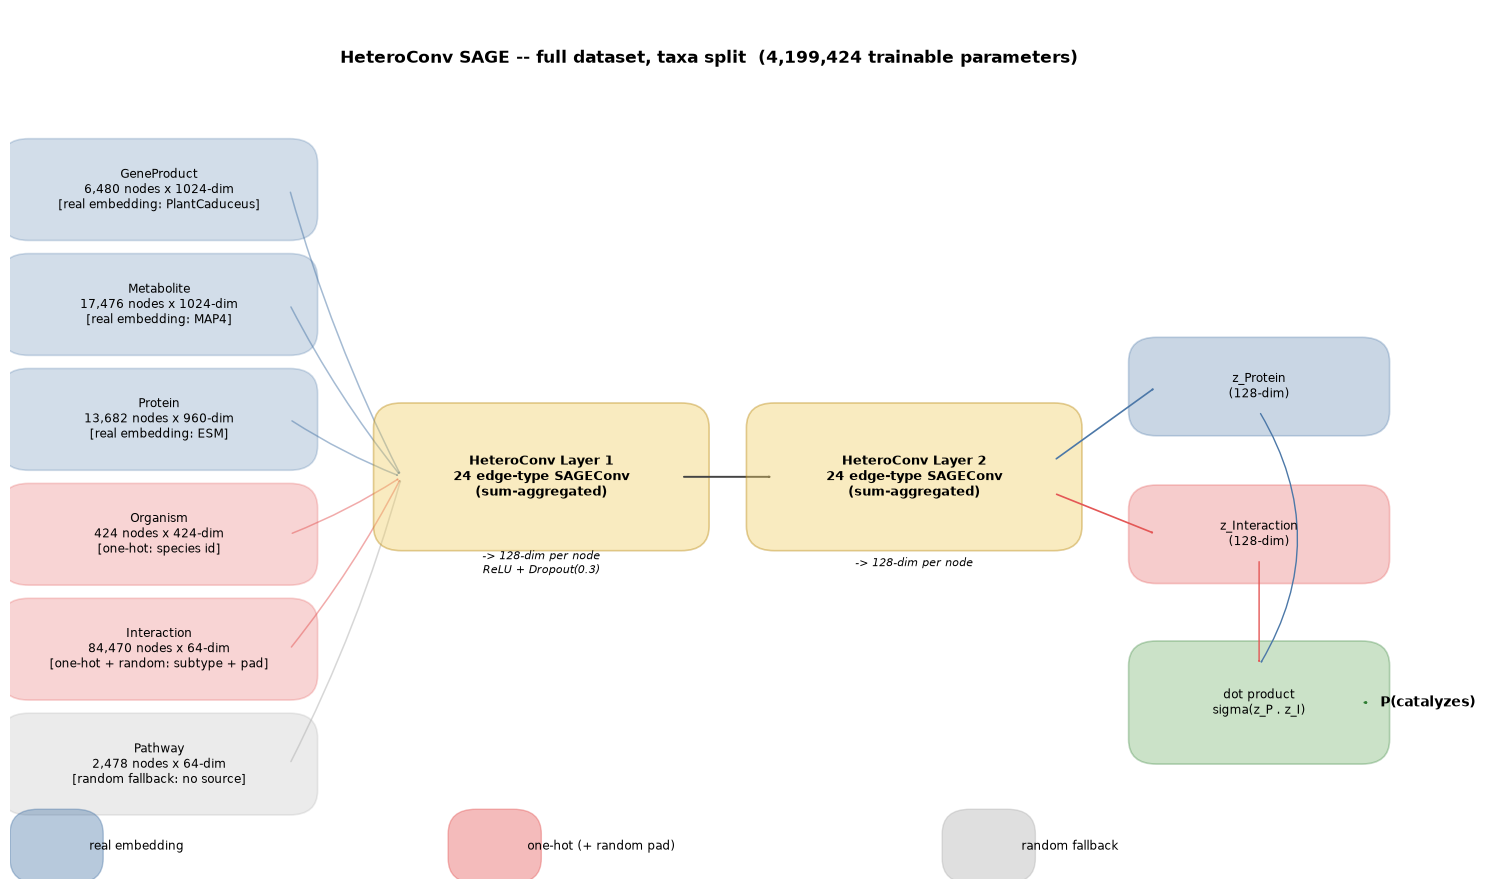

Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/reports/figures/04_model_architecture.png


In [7]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

FEATURE_SOURCE = {
    "Protein":     ("real embedding",  "ESM",          "#4C78A8"),
    "Metabolite":  ("real embedding",  "MAP4",         "#4C78A8"),
    "GeneProduct": ("real embedding",  "PlantCaduceus","#4C78A8"),
    "Interaction": ("one-hot + random","subtype + pad","#E45756"),
    "Organism":    ("one-hot",         "species id",   "#E45756"),
    "DataNode":    ("random fallback", "no source",    "#B0B0B0"),
    "External":    ("random fallback", "no source",    "#B0B0B0"),
    "Pathway":     ("random fallback", "no source",    "#B0B0B0"),
}
node_types = sorted(ctx.train_data.node_types, key=lambda nt: -ctx.train_data[nt].x.shape[1])
n_edge_types = len(model.convs[0].convs)

fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 15)
ax.set_ylim(-0.4, 10.2)
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.3", linewidth=1.2)
n = len(node_types)
ys = np.linspace(8.0, 1.0, n)
left_x, mid1_x, mid2_x, mid3_x = 1.6, 5.7, 9.7, 13.4

for nt, y in zip(node_types, ys):
    n_nodes = ctx.train_data[nt].num_nodes
    dim = ctx.train_data[nt].x.shape[1]
    source, detail, color = FEATURE_SOURCE[nt]
    label = f"{nt}\n{n_nodes:,} nodes x {dim}-dim\n[{source}: {detail}]"
    box = FancyBboxPatch((left_x - 1.4, y - 0.32), 2.8, 0.64, facecolor=color, alpha=0.25,
                          edgecolor=color, **box_style)
    ax.add_patch(box)
    ax.text(left_x, y, label, ha="center", va="center", fontsize=8.5)
    ax.add_patch(FancyArrowPatch((left_x + 1.4, y), (mid1_x - 1.5, 4.5),
                                  arrowstyle="-|>", color=color, alpha=0.5, linewidth=1.1,
                                  connectionstyle="arc3,rad=0.05"))

conv1 = FancyBboxPatch((mid1_x - 1.5, 3.9), 3.0, 1.2,
                        facecolor="#F1CE63", alpha=0.4, edgecolor="#B8860B", **box_style)
ax.add_patch(conv1)
ax.text(mid1_x, 4.5, f"HeteroConv Layer 1\n{n_edge_types} edge-type SAGEConv\n(sum-aggregated)",
        ha="center", va="center", fontsize=9, weight="bold")
ax.text(mid1_x, 3.45, "-> 128-dim per node\nReLU + Dropout(0.3)", ha="center", va="center", fontsize=8, style="italic")

ax.add_patch(FancyArrowPatch((mid1_x + 1.5, 4.5), (mid2_x - 1.5, 4.5),
                              arrowstyle="-|>", color="#444", linewidth=1.4))
conv2 = FancyBboxPatch((mid2_x - 1.5, 3.9), 3.0, 1.2,
                        facecolor="#F1CE63", alpha=0.4, edgecolor="#B8860B", **box_style)
ax.add_patch(conv2)
ax.text(mid2_x, 4.5, f"HeteroConv Layer 2\n{n_edge_types} edge-type SAGEConv\n(sum-aggregated)",
        ha="center", va="center", fontsize=9, weight="bold")
ax.text(mid2_x, 3.45, "-> 128-dim per node", ha="center", va="center", fontsize=8, style="italic")

pz = FancyBboxPatch((mid3_x - 1.1, 5.3), 2.2, 0.6, facecolor="#4C78A8", alpha=0.3, edgecolor="#4C78A8", **box_style)
ax.add_patch(pz)
ax.text(mid3_x, 5.6, "z_Protein\n(128-dim)", ha="center", va="center", fontsize=8.5)
iz = FancyBboxPatch((mid3_x - 1.1, 3.5), 2.2, 0.6, facecolor="#E45756", alpha=0.3, edgecolor="#E45756", **box_style)
ax.add_patch(iz)
ax.text(mid3_x, 3.8, "z_Interaction\n(128-dim)", ha="center", va="center", fontsize=8.5)

ax.add_patch(FancyArrowPatch((mid2_x + 1.5, 4.7), (mid3_x - 1.1, 5.6),
                              arrowstyle="-|>", color="#4C78A8", linewidth=1.2))
ax.add_patch(FancyArrowPatch((mid2_x + 1.5, 4.3), (mid3_x - 1.1, 3.8),
                              arrowstyle="-|>", color="#E45756", linewidth=1.2))

decoder = FancyBboxPatch((mid3_x - 1.1, 1.3), 2.2, 0.9, facecolor="#54A24B", alpha=0.3, edgecolor="#2E7D32", **box_style)
ax.add_patch(decoder)
ax.text(mid3_x, 1.75, "dot product\nsigma(z_P . z_I)", ha="center", va="center", fontsize=8.5)
ax.add_patch(FancyArrowPatch((mid3_x, 5.3), (mid3_x, 2.2), arrowstyle="-|>", color="#4C78A8", linewidth=1.0,
                              connectionstyle="arc3,rad=-0.3"))
ax.add_patch(FancyArrowPatch((mid3_x, 3.5), (mid3_x, 2.2), arrowstyle="-|>", color="#E45756", linewidth=1.0))

ax.text(14.7, 1.75, "P(catalyzes)", ha="left", va="center", fontsize=10, weight="bold")
ax.add_patch(FancyArrowPatch((mid3_x + 1.1, 1.75), (14.6, 1.75), arrowstyle="-|>", color="#2E7D32", linewidth=1.4))

ax.text(7.5, 9.6, f"HeteroConv SAGE -- full dataset, taxa split  ({n_params:,} trainable parameters)",
        ha="center", va="center", fontsize=12, weight="bold")

legend_y = -0.15
legend_items = [("real embedding", "#4C78A8", 0.3), ("one-hot (+ random pad)", "#E45756", 5.0),
                 ("random fallback", "#B0B0B0", 10.3)]
for label, color, x0 in legend_items:
    ax.add_patch(FancyBboxPatch((x0, legend_y), 0.4, 0.3, facecolor=color, alpha=0.4, edgecolor=color))
    ax.text(x0 + 0.55, legend_y + 0.15, label, ha="left", va="center", fontsize=8.5)

plt.tight_layout()
fig.savefig(FIG_DIR_DEFAULT / "04_model_architecture.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR_DEFAULT}/04_model_architecture.png")

### 4.2 Known issue: representation collapse at full-dataset scale (confirmed, not just suspected)

`learnathon/LEARNATHON_BASELINE_MODEL.md` already *suspected* that all
Catalysis-subtype Interaction nodes sharing an identical one-hot input
vector (no per-node signal until message passing differentiates them)
contributes to H@K collapsing while AUC stays healthy, and introduced
`--interaction-extra-dim` as a mitigation. At full-dataset scale this is no
longer just a suspicion: with `INTERACTION_EXTRA_DIM = 0`, a 150-epoch run
(`--early-stop-patience 0`, everything else identical to this notebook's
defaults) gave val AUC ~0.82-0.86 throughout -- the model clearly learns
*something* -- while val H@10 and H@50 stayed at **exactly 0.0** for all 150
epochs (the only nonzero H@50 over the whole run, 0.016, was a fluke at
epoch 1, before any real training had happened, which is what triggered an
extra failure mode: early stopping locks onto that fluke as "best" and
never gets a chance to beat it).

With `INTERACTION_EXTRA_DIM = 16` (this notebook's default, also now the
default in `training/fulldata_baseline_train.py` -- unlike
`learnathon_baseline_train.py`'s, which keeps 0 for comparability with its
own established results), the same 150-epoch run instead reaches val
H@50 ~0.07 (~18x the random baseline) and H@10 ~0.02 (~28x random), climbing
steadily rather than sitting at zero. Pass `INTERACTION_EXTRA_DIM = 0` to
reproduce the collapse yourself.

**Why it works, mechanistically (not just "it empirically helps"):**
`SAGEConv`'s update is `h_v' = W1.h_v + W2.AGG(neighbours of v)`. With
`INTERACTION_EXTRA_DIM = 0`, every one of the 12,359 Catalysis Interaction
nodes starts from the *identical* 6-dim one-hot vector -- so the self-term
`W1.h_v` is bit-for-bit identical across all of them, for every node in the
H@K ranking pool. The only thing that could differentiate two Interaction
nodes is `W2.AGG(neighbours)`. In principle that should be enough (different
nodes do have different neighbourhoods) -- but BCE against fixed 1:1 random
negatives (what AUC/AP measure) only needs *true pairs to score higher than
random pairs on average*, a far weaker constraint than H@K's "rank this one
true Interaction above the other 12,358 -- all of which are also genuine
Catalysis edges, just for other proteins." Nothing in that training signal
explicitly penalises many different Interaction embeddings drifting toward
the same region of space, as long as that region scores well against
*typical* random negatives -- which is exactly the AUC-good/H@K-collapsed
signature observed above. Appending a small **fixed, per-node random
vector** (seeded once, not re-randomised every epoch) breaks the input-level
symmetry: `h_v` is no longer identical across nodes, so `W1.h_v` is
automatically distinguishable per node from epoch 0, independent of whether
the loss gradient would have bothered to preserve a node-specific signal
through the neighbourhood term alone. This is a known GNN technique (Sato et
al. 2021, *"Random Features Strengthen Graph Neural Networks"*) for exactly
this failure mode: message-passing GNNs are bounded by the Weisfeiler-Leman
test and can't distinguish nodes that look locally similar when they start
from identical (or absent) input features.

This is the clearest evidence yet that the collapse is a real architectural
issue (degenerate inputs for the entire H@K ranking pool), not noise --
worth keeping in mind before trusting H@K numbers from *any* run that
doesn't use this flag, on either dataset.

## 5. Training

AdamW + gradient-clip + early-stop on val-H@50.  Structural choices are baked
into the loaded data (see S1), so no forward-pass flag is needed:

| Setting | Where | Why |
|---|---|---|
| `is_part_of` removed | `load_taxa_splits(remove_is_part_of=True)` | No Pathway co-membership in GNN embeddings |
| `catalyzed_by` removed | `load_taxa_splits(...)` | No 2-hop P->C->P training shortcut |
| `disjoint_train_ratio=0.2` | `load_taxa_splits(...)` | 20% of train positives supervision-only; no 1-hop shortcut |

Training negatives: `NEG_K` corrupt-Conversion pairs `(P, C_random)` per
positive, drawn from the full Conversion pool (excluding known true pairs).


### 5.1 Note: pathway-pool hard negatives removed

Same-Pathway hard negatives (`build_pathway_pools` + `train_step_hard_negs`
with `neg_k_hard>0`) and cross-organism negatives required `is_part_of` edges
to be present in the data.  Since `remove_is_part_of=True` is the default,
these are not available here.  To experiment with them, call
`load_taxa_splits(remove_is_part_of=False)` and pass `neg_k_hard>0`.
The simplified training loop below uses only in-pool random negatives.


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

rng = np.random.default_rng(RANDOM_SEED)
exclude_pairs = collect_true_positive_pairs(ctx) if NEG_K > 0 else None
if NEG_K > 0:
    print(f"In-pool random negatives: {NEG_K} per positive "
          f"({len(exclude_pairs)} known true pairs excluded)")
print(f"Disjoint train ratio: {DISJOINT_TRAIN_RATIO}")
print(f"EC features: {'ON' if EC_FEATURES else 'off'}  "
      f"Interaction feature dim: {ctx.train_data['Interaction'].x.shape[-1]}")

history = {
    "train_loss": [], "val_auc": [], "val_ap": [], "val_loss": [],
    "test_loss": [], "val_h10": [], "val_h50": [],
}
best_val_h50 = -1.0
best_path = CKPT_DIR_DEFAULT / f"{RUN_NAME}_best.pt"
epochs_since_improve = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    loss, diverged = train_step_hard_negs(
        model, predictor, optimizer, ctx, ctx.train_data,
        neg_k_random=NEG_K, neg_k_hard=0, neg_k_cp=0,
        rng=rng, exclude_pairs=exclude_pairs, pools=None,
        no_mp_is_part_of=False,  # edges already removed at load time
    )
    if diverged:
        print(f"Epoch {epoch}: divergence detected -- stopping early.")
        break
    val_auc, val_ap, val_loss = evaluate_fulldata(
        model, predictor, ctx.val_data, ctx.target_edge,
    )
    _, _, test_loss = evaluate_fulldata(
        model, predictor, ctx.test_data, ctx.target_edge,
    )
    val_hk = hits_at_k_fulldata(model, predictor, ctx.val_data, ctx)
    dt = time.time() - t0

    history["train_loss"].append(loss)
    history["val_auc"].append(val_auc)
    history["val_ap"].append(val_ap)
    history["val_loss"].append(val_loss)
    history["test_loss"].append(test_loss)
    history["val_h10"].append(val_hk["H@10"])
    history["val_h50"].append(val_hk["H@50"])

    ckpt = {
        "epoch": epoch, "model_state": model.state_dict(), "predictor_state": predictor.state_dict(),
        "optimizer_state": optimizer.state_dict(), "val_auc": val_auc, "val_ap": val_ap,
        "val_loss": val_loss, "test_loss": test_loss,
        "val_h10": val_hk["H@10"], "val_h50": val_hk["H@50"],
        "hparams": {
            "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS, "dropout": DROPOUT,
            "lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
            "neg_k": NEG_K, "disjoint_train_ratio": DISJOINT_TRAIN_RATIO,
            "ec_features": EC_FEATURES,
            "dataset": "full_dataset", "split": "taxa",
            "interaction_feature_dim": int(ctx.train_data["Interaction"].x.shape[-1]),
        },
    }
    if val_hk["H@50"] > best_val_h50:
        best_val_h50 = val_hk["H@50"]
        epochs_since_improve = 0
        torch.save(ckpt, best_path)
    else:
        epochs_since_improve += 1
    if epoch % 10 == 0:
        torch.save(ckpt, CKPT_DIR_DEFAULT / f"{RUN_NAME}_epoch{epoch:03d}.pt")
        print(f"Epoch {epoch:3d}  loss={loss:.4f}  val_loss={val_loss:.4f}  test_loss={test_loss:.4f}  "
              f"val_AUC={val_auc:.4f}  val_AP={val_ap:.4f}  "
              f"val_H@10={val_hk['H@10']:.4f}  val_H@50={val_hk['H@50']:.4f}  ({dt:.2f}s/epoch)")
    if EARLY_STOP_PATIENCE > 0 and epochs_since_improve >= EARLY_STOP_PATIENCE:
        print(f"Epoch {epoch}: no val H@50 improvement in {EARLY_STOP_PATIENCE} epochs -- stopping early.")
        break

best_ckpt = torch.load(best_path, weights_only=False)
model.load_state_dict(best_ckpt["model_state"])
predictor.load_state_dict(best_ckpt["predictor_state"])
print(f"\nBest val H@50: {best_ckpt['val_h50']:.4f}  (epoch {best_ckpt['epoch']})  "
      f"H@10={best_ckpt['val_h10']:.4f}  AUC={best_ckpt['val_auc']:.4f}  AP={best_ckpt['val_ap']:.4f}")
print(f"Checkpoint -> {best_path}")


## 6. Results and evaluation metrics

Three metrics:

- **AUC / AP** on fixed 1:1 random negatives in `edge_label_index` (fast
  pairwise check; note random baseline is near 0.5 since Pathway shortcut removed).
- **P-H@K** (Protein Hits at K): for each val/test positive, rank all embedded
  proteins against the reaction; hit if true catalyst in top K.
  Random baseline approx 0.59% at K=50.  **Primary metric.**
- **Paralog diagnostic** (S6.2): cosine similarity between test proteins and
  closest training protein for the same reaction.


In [ ]:
val_auc, val_ap, val_loss = evaluate_fulldata(
    model, predictor, ctx.val_data, ctx.target_edge,
)
test_auc, test_ap, test_loss = evaluate_fulldata(
    model, predictor, ctx.test_data, ctx.target_edge,
)
val_hk  = hits_at_k_fulldata(model, predictor, ctx.val_data,  ctx)
test_hk = hits_at_k_fulldata(model, predictor, ctx.test_data, ctx)

print(f"{'':38} {'AUC':>8} {'AP':>8} {'H@10':>8} {'H@50':>8}")
print("-" * 72)
print(f"{'HeteroConv SAGE  (val)' :<38} {val_auc:>8.4f} {val_ap:>8.4f} "
      f"{val_hk['H@10']:>8.4f} {val_hk['H@50']:>8.4f}")
print(f"{'HeteroConv SAGE  (test)':<38} {test_auc:>8.4f} {test_ap:>8.4f} "
      f"{test_hk['H@10']:>8.4f} {test_hk['H@50']:>8.4f}")


### 6.3 Paralog/isoenzyme leakage: does the model rely on sequence similarity?

For test positives (P_test, C) where the same Conversion C also appears in
training (see §2.2 -- this is most of the test set), `paralog_leakage_diagnostic()`
computes the **maximum cosine similarity** between P_test's GNN embedding and any
training protein that catalyses the same C.

- High mean similarity (>0.8) → the model may succeed not because it learned
  enzyme-substrate specificity but because "P_test looks like the training
  protein for this reaction". This is the isoenzyme/paralog leakage case:
  homologous enzymes share sequences, so their embeddings land near each other
  even without learning specificity. In this regime, within-Pathway H@K is
  inflated because homologs of the true enzyme rank near the top.
- Low mean similarity (<0.4) → the model is genuinely generalising to
  sequence-dissimilar proteins, which suggests it picked up substrate chemistry
  or structural features rather than just protein identity.

Note: this diagnostic uses the current model's embeddings (trained with `is_part_of`
edges and real ESM/MAP4 inputs). A fair "no-leakage" baseline would need a model
trained on *only organisms with no Conversion overlap* -- but the signal here
is still useful as a directional check.

In [ ]:
para = paralog_leakage_diagnostic(model, ctx, ctx.test_data)
print("Paralog/isoenzyme leakage diagnostic (test set):")
print(f"  Test positives                : {para['n_test_positives']}")
print(f"  ...with Conversion in training: {para['n_with_train_conversion_overlap']} "
      f"({para['conversion_overlap_rate']:.1%})")
print()
print("  Cosine similarity: P_test vs. closest training protein for same Conversion:")
print(f"    Mean max cosine sim   : {para['mean_max_cosine_sim']:.4f}")
print(f"    Median max cosine sim : {para['median_max_cosine_sim']:.4f}")
print(f"    Fraction with sim > 0.9 (near-identical): {para['frac_sim_above_0p9']:.1%}")
print(f"    Fraction with sim > 0.5 (similar family): {para['frac_sim_above_0p5']:.1%}")
print()
print("  Old model (with is_part_of): mean sim=0.72, 90.9% above 0.5")
print("  Interpretation:")
if para['mean_max_cosine_sim'] > 0.7:
    print("  HIGH similarity -- strong paralog/isoenzyme leakage likely.")
    print("  Protein embedding space is still mostly driven by sequence similarity.")
elif para['mean_max_cosine_sim'] > 0.4:
    print("  MODERATE similarity -- partial leakage; model uses some protein-specific signal.")
else:
    print("  LOW similarity -- model generalises beyond sequence similarity. Good sign.")

## 7. Learning curves

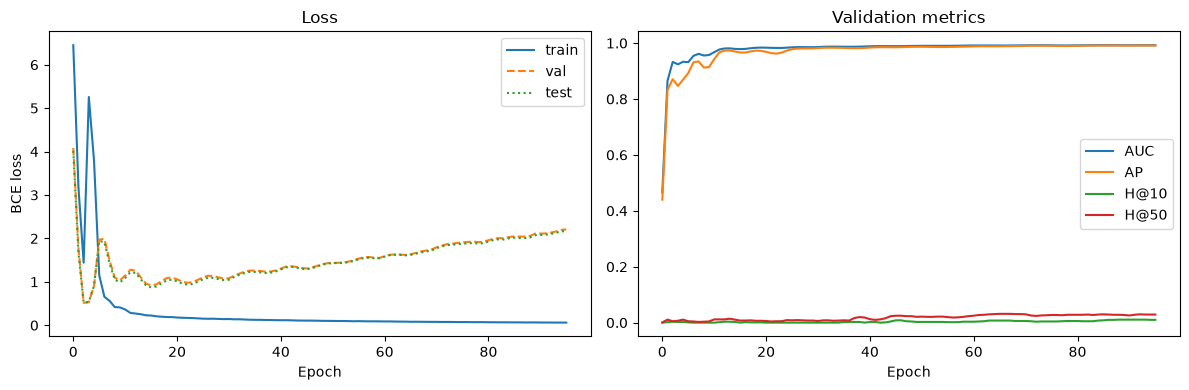

Saved -> /lustre/BIF/nobackup/delp003/path-graph-ml/reports/figures/04_fulldata_learning_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train", linestyle="-")
axes[0].plot(history["val_loss"],   label="val",   linestyle="--")
axes[0].plot(history["test_loss"],  label="test",  linestyle=":")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_auc"], label="AUC")
axes[1].plot(history["val_ap"],  label="AP")
axes[1].plot(history["val_h10"], label="H@10")
axes[1].plot(history["val_h50"], label="H@50")
axes[1].set_xlabel("Epoch")
axes[1].set_title("Validation metrics")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR_DEFAULT / "04_fulldata_learning_curves.png", dpi=150)
plt.show()
print(f"Saved -> {FIG_DIR_DEFAULT}/04_fulldata_learning_curves.png")

## 8. Current setup summary and next steps

### Active defaults

| Setting | Value | Why |
|---|---|---|
| `remove_is_part_of` | `True` | No Pathway co-membership in GNN embeddings |
| `catalyzed_by` reverse edge | removed | No 2-hop P->C->P training shortcut |
| `disjoint_train_ratio` | `0.2` | 20% of train positives supervision-only; no 1-hop shortcut |
| Primary metric | P-H@50 | True catalyst in top 50 of 8,445 embedded proteins |

### Next steps

- **Notebook 05**: post-hoc pathway analysis -- do top-K predictions
  reconstruct the original WikiPathways pathway structure?
- **Architecture**: try GAT, HGT, or GIN in `models.py`.
- **Edge split**: call `load_edge_splits()` for the easier transductive task.
- **EC features**: add 8-dim EC-class one-hot on Conversion nodes.
